##**Step 5: Critical  Thinking, Ethical AI and Bias Auditing**

This step evaluates whether the Logistic Regression champion is sufficiently explainable, fair, stable, and governable for use as a fraud-review prioritization tool. The model must not be treated as an automatic rejection mechanism. Its purpose is to rank applications for human investigation, because false positives may inconvenience legitimate applicants while false negatives may expose the institution to fraud losses.


The analysis uses Logistic Regression coefficients, SHAP, Partial Dependence Plots, and Individual Conditional Expectation curves. It also evaluates class imbalance, temporal drift, preprocessing leakage, overfitting, probability calibration, subgroup performance, fairness gaps, threshold sensitivity, and reweighting as a mitigation experiment.

**a. Confirm the Audited Model and Results**

This cell verifies that Step 5 is auditing the actual Logistic Regression champion produced in Step 4.

In [ ]:
# Confirm the model and Step 4 outputs used for auditing

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_step5_objects = [
    "champion_model",
    "champion_name",
    "champion_threshold",
    "champion_valid_score",
    "champion_test_score",
    "variant_test_score",
    "X_train_full",
    "y_train_full",
    "X_valid",
    "y_valid",
    "X_test",
    "y_test",
    "X_variant_test",
    "y_variant_test"
]

missing_objects = [
    name for name in required_step5_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run Step 4 before Step 5. Missing objects: "
        + ", ".join(missing_objects)
    )

STEP5_REPORT_DIR = REPORT_DIR / "step5"
STEP5_REPORT_DIR.mkdir(parents=True, exist_ok=True)

step5_model_snapshot = pd.DataFrame({
    "item": [
        "Audited model",
        "Selected threshold",
        "Base test PR-AUC",
        "Base test ROC-AUC",
        "Base fixed-threshold recall",
        "Base fixed-threshold precision",
        "Base top-10% recall",
        "Variant II PR-AUC",
        "Variant II fixed-threshold recall",
        "Variant II fixed-threshold precision",
        "Variant II top-10% recall"
    ],
    "value": [
        champion_name,
        champion_threshold,
        base_test_results.iloc[0]["pr_auc"],
        base_test_results.iloc[0]["roc_auc"],
        base_test_results.iloc[0]["recall"],
        base_test_results.iloc[0]["precision"],
        base_test_results.iloc[0]["recall_at_k"],
        variant_test_results.iloc[0]["pr_auc"],
        variant_test_results.iloc[0]["recall"],
        variant_test_results.iloc[0]["precision"],
        variant_test_results.iloc[0]["recall_at_k"]
    ]
})

display(step5_model_snapshot)

,item,value
0,Audited model,Logistic Regression
1,Selected threshold,0.65813
2,Base test PR-AUC,0.198539
3,Base test ROC-AUC,0.890668
4,Base fixed-threshold recall,0.627451
5,Base fixed-threshold precision,0.114067
6,Base top-10% recall,0.670168
7,Variant II PR-AUC,0.201282
8,Variant II fixed-threshold recall,0.717087
9,Variant II fixed-threshold precision,0.081483


**b. Explainability Scope**

The champion is a Logistic Regression pipeline using median imputation, robust scaling, one-hot encoding, class weighting, and the best regularization value identified during tuning. Logistic Regression is relatively transparent because each transformed feature has a coefficient. Positive coefficients increase predicted fraud log-odds, while negative coefficients reduce them, holding the other modeled features constant.


These relationships are predictive associations, not causal conclusions. A positive coefficient does not establish that the corresponding characteristic causes fraud.

**c. Global Explanation Using Logistic Regression Coefficients**

The following code extracts the fitted coefficients and converts them into an auditable table. The odds ratio is also reported, although it must be interpreted with the preprocessing applied to each feature.

In [ ]:
# Extract global Logistic Regression coefficients

from sklearn.linear_model import LogisticRegression

fitted_preprocessor = champion_model.named_steps["preprocessor"]
fitted_estimator = champion_model.named_steps["model"]

if not isinstance(fitted_estimator, LogisticRegression):
    raise TypeError(
        "This Step 5 version expects the notebook's "
        "Logistic Regression champion."
    )

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

coefficients = fitted_estimator.coef_.ravel()

coefficient_summary = pd.DataFrame({
    "feature": transformed_feature_names,
    "coefficient": coefficients
})

coefficient_summary["absolute_coefficient"] = (
    coefficient_summary["coefficient"].abs()
)

# Clip only for stable odds-ratio display.
coefficient_summary["odds_ratio"] = np.exp(
    coefficient_summary["coefficient"].clip(
        lower=-20,
        upper=20
    )
)

coefficient_summary["direction"] = np.where(
    coefficient_summary["coefficient"] > 0,
    "Increases predicted fraud risk",
    "Decreases predicted fraud risk"
)

coefficient_summary = (
    coefficient_summary
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(coefficient_summary.head(30))

,feature,coefficient,absolute_coefficient,odds_ratio,direction
0,numeric__multiple_emails_per_device_flag,1.628226,1.628226,5.094830,Increases predicted fraud risk
1,numeric__prev_address_months_count_unknown_flag,1.502838,1.502838,4.494425,Increases predicted fraud risk
2,numeric__has_other_cards,-1.180329,1.180329,0.307178,Decreases predicted fraud risk
3,numeric__phone_home_valid,-0.991625,0.991625,0.370973,Decreases predicted fraud risk
4,categorical__housing_status_BA,0.957538,0.957538,2.605276,Increases predicted fraud risk
5,numeric__intended_balcon_negative_flag,0.823175,0.823175,2.277721,Increases predicted fraud risk
6,numeric__keep_alive_session,-0.676790,0.676790,0.508246,Decreases predicted fraud risk
7,numeric__log_proposed_credit_limit,-0.644278,0.644278,0.525042,Decreases predicted fraud risk
8,numeric__credit_risk_score,0.625437,0.625437,1.869062,Increases predicted fraud risk
9,numeric__velocity_24h,-0.613423,0.613423,0.541494,Decreases predicted fraud risk


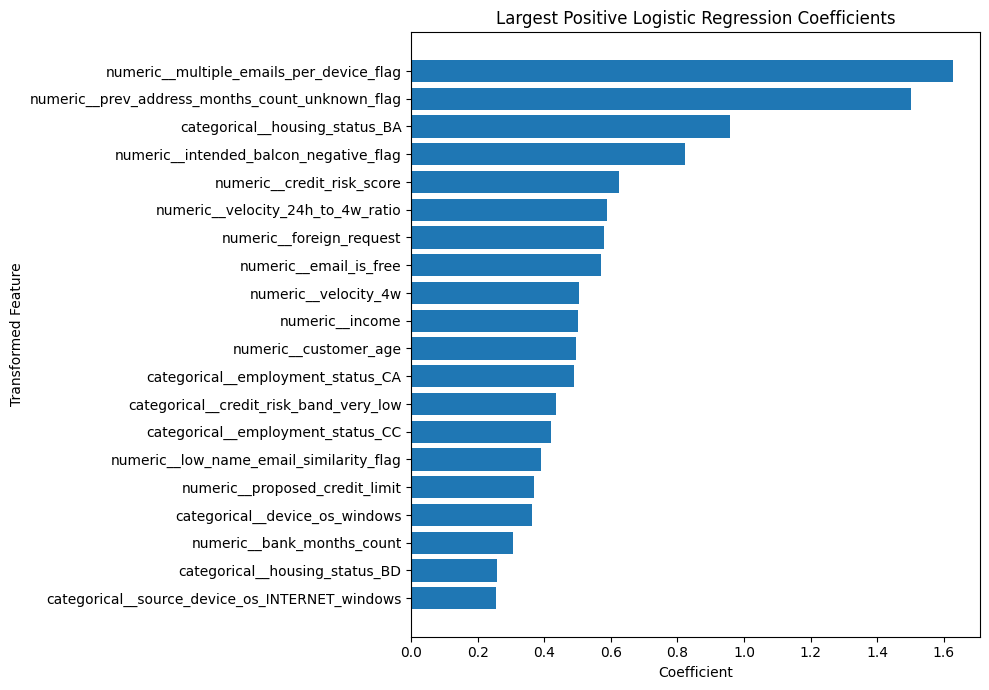

In [ ]:
# Largest positive coefficients

positive_coefficients = (
    coefficient_summary[
        coefficient_summary["coefficient"] > 0
    ]
    .nlargest(20, "coefficient")
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 7))
plt.barh(
    positive_coefficients["feature"],
    positive_coefficients["coefficient"]
)
plt.title("Largest Positive Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Transformed Feature")
plt.tight_layout()
plt.show()

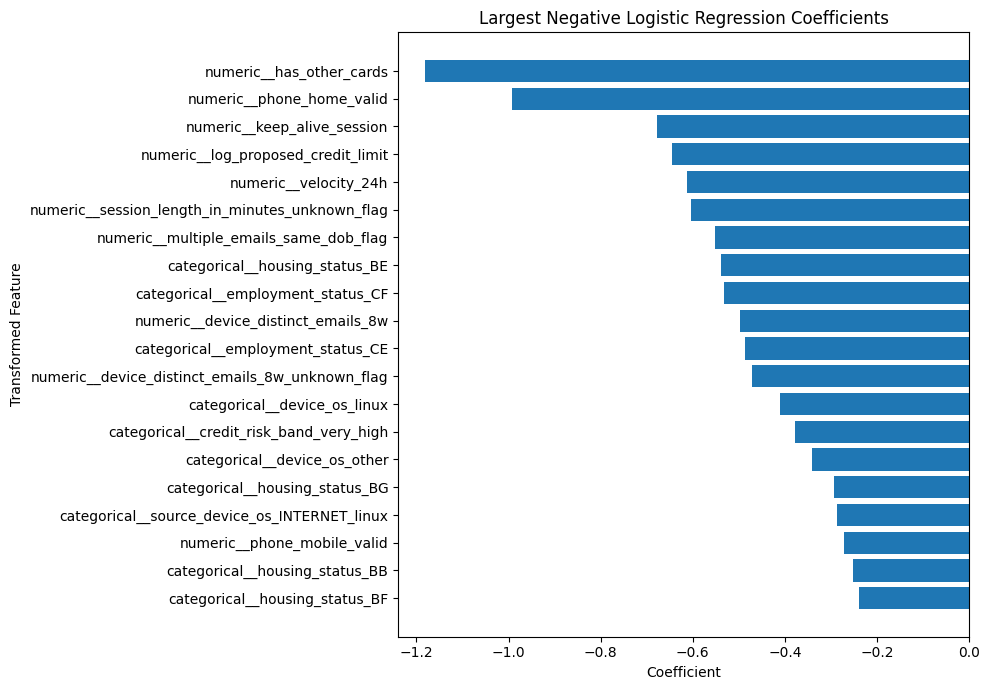

In [ ]:
# Largest negative coefficients

negative_coefficients = (
    coefficient_summary[
        coefficient_summary["coefficient"] < 0
    ]
    .nsmallest(20, "coefficient")
    .sort_values("coefficient", ascending=False)
)

plt.figure(figsize=(10, 7))
plt.barh(
    negative_coefficients["feature"],
    negative_coefficients["coefficient"]
)
plt.title("Largest Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Transformed Feature")
plt.tight_layout()
plt.show()

**Result interpretation.** The fitted coefficients confirm the domain patterns identified in Step 3. The strongest positive associations with predicted fraud were multiple emails on one device (`+1.628`), unknown previous-address history (`+1.503`), housing status BA (`+0.958`), a negative intended-balance flag (`+0.823`), credit-risk score (`+0.625`), foreign request (`+0.578`), free-email use (`+0.569`), income (`+0.501`), and customer age (`+0.495`). The strongest negative associations included having other cards (`-1.180`), a valid home phone (`-0.992`), keep-alive sessions (`-0.677`), log proposed credit limit (`-0.644`), and 24-hour velocity (`-0.613`). These are predictive associations after preprocessing, not causal statements. Housing, income, employment, and age require particular governance attention because they can operate as demographic or socioeconomic proxies.

**d. Model Explanation Using SHAP**

SHAP provides a second explanation method. For Logistic Regression, SHAP values describe how each transformed feature moves the model output away from its baseline. These values are generally expressed in the model’s linear or log-odds space rather than as direct probability changes.

In [ ]:
# Prepare a manageable SHAP sample

import shap
from scipy import sparse

SHAP_BACKGROUND_SIZE = min(500, len(X_train_full))
SHAP_EVALUATION_SIZE = min(1500, len(X_test))

X_shap_background = X_train_full.sample(
    n=SHAP_BACKGROUND_SIZE,
    random_state=SEED
)

X_shap_evaluation = X_test.sample(
    n=SHAP_EVALUATION_SIZE,
    random_state=SEED
)

background_transformed = fitted_preprocessor.transform(
    X_shap_background
)

evaluation_transformed = fitted_preprocessor.transform(
    X_shap_evaluation
)

if sparse.issparse(background_transformed):
    background_for_shap = background_transformed.toarray()
else:
    background_for_shap = np.asarray(background_transformed)

if sparse.issparse(evaluation_transformed):
    evaluation_for_shap = evaluation_transformed.toarray()
else:
    evaluation_for_shap = np.asarray(evaluation_transformed)

shap_explainer = shap.LinearExplainer(
    fitted_estimator,
    background_for_shap
)

shap_values = shap_explainer(
    evaluation_for_shap
)

shap_values.feature_names = list(
    transformed_feature_names
)

print("SHAP explanation shape:", shap_values.values.shape)

SHAP explanation shape: (1500, 91)


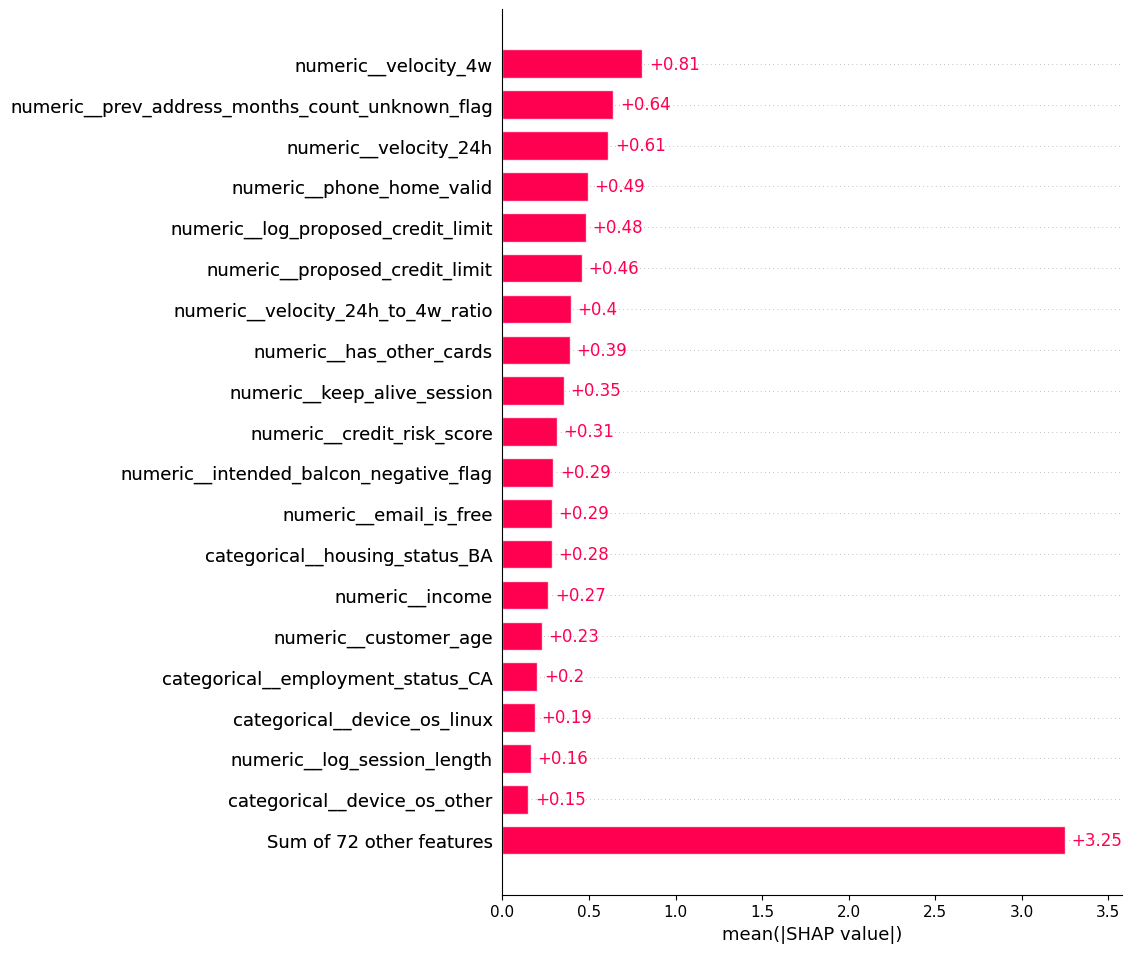

In [ ]:
# Global SHAP importance

shap.plots.bar(
    shap_values,
    max_display=20
)

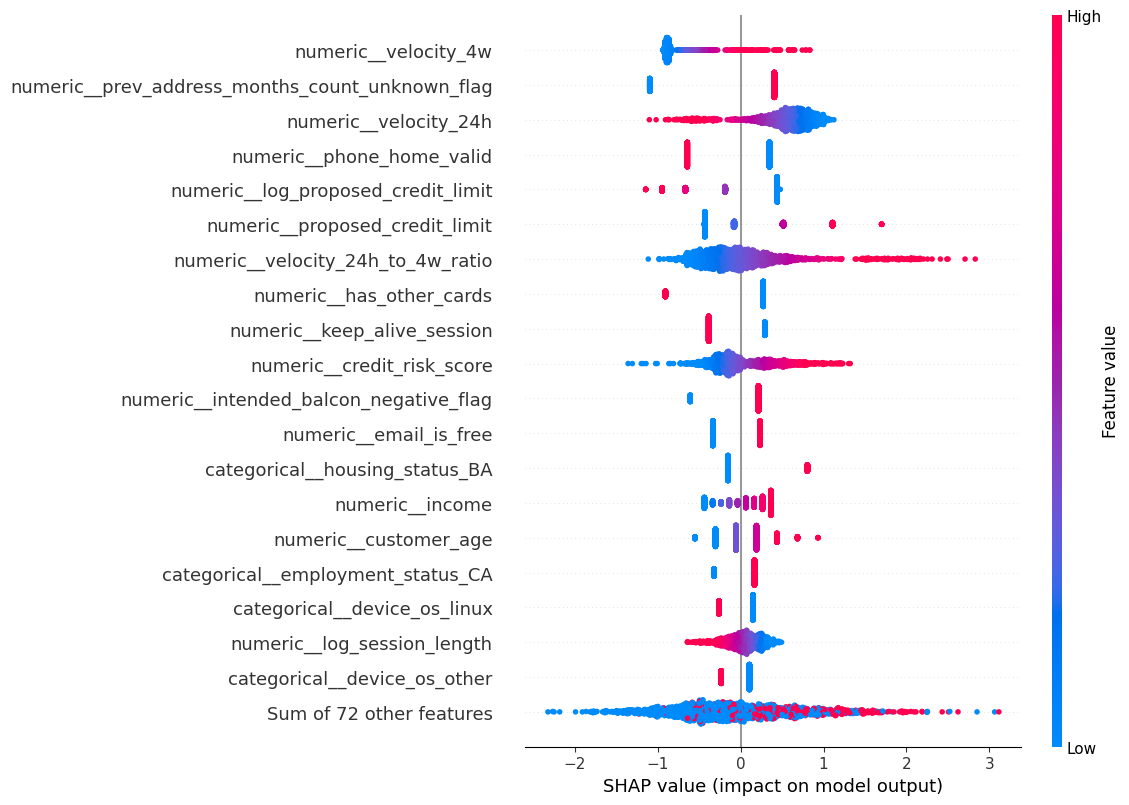

In [ ]:
# SHAP direction and distribution

shap.plots.beeswarm(
    shap_values,
    max_display=20
)

**SHAP interpretation.** Global SHAP importance broadly supports the coefficient analysis. Four-week velocity, unknown previous-address history, 24-hour velocity, phone validity, proposed credit limit, the 24-hour-to-four-week velocity ratio, card ownership, session persistence, credit-risk score, negative intended balance, free-email use, housing BA, income, and age were among the strongest drivers. The SHAP direction plot showed that higher four-week velocity, a missing previous-address history, higher velocity ratios, higher credit-risk scores, free-email use, higher income, and older age generally moved predictions toward fraud. In contrast, valid home phones, having other cards, keep-alive sessions, and higher 24-hour velocity generally reduced the predicted risk. The local waterfall plots also show why false positives and false negatives must remain subject to analyst review rather than automated rejection.

**e. Local Explanations for Correct and Incorrect Decisions**

An exemplary analysis should explain incorrect cases as well as successful detections. The following code selects one true positive, false positive, false negative, and true negative. False-positive and false-negative cases are important because they represent customer-friction and fraud-loss risks.

In [ ]:
# Identify representative prediction outcomes

test_predictions = (
    champion_test_score >= champion_threshold
).astype(int)

case_results = pd.DataFrame({
    "position": np.arange(len(y_test)),
    "actual": np.asarray(y_test),
    "prediction": test_predictions,
    "score": champion_test_score
})

case_results["outcome"] = np.select(
    [
        (case_results["actual"] == 1)
        & (case_results["prediction"] == 1),

        (case_results["actual"] == 0)
        & (case_results["prediction"] == 1),

        (case_results["actual"] == 1)
        & (case_results["prediction"] == 0),

        (case_results["actual"] == 0)
        & (case_results["prediction"] == 0)
    ],
    [
        "True Positive",
        "False Positive",
        "False Negative",
        "True Negative"
    ],
    default="Unknown"
)

display(
    case_results["outcome"]
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="count")
)

,outcome,count
0,True Negative,88456
1,False Positive,6959
2,True Positive,896
3,False Negative,532


In [ ]:
# Select informative representative cases

representative_positions = {}

# Highest-risk correctly detected fraud
tp_cases = case_results[
    case_results["outcome"] == "True Positive"
]
if not tp_cases.empty:
    representative_positions["True Positive"] = int(
        tp_cases.loc[tp_cases["score"].idxmax(), "position"]
    )

# Highest-risk legitimate application
fp_cases = case_results[
    case_results["outcome"] == "False Positive"
]
if not fp_cases.empty:
    representative_positions["False Positive"] = int(
        fp_cases.loc[fp_cases["score"].idxmax(), "position"]
    )

# Missed fraud closest to the operational threshold
fn_cases = case_results[
    case_results["outcome"] == "False Negative"
]
if not fn_cases.empty:
    representative_positions["False Negative"] = int(
        fn_cases.loc[fn_cases["score"].idxmax(), "position"]
    )

# Legitimate application closest to the threshold
tn_cases = case_results[
    case_results["outcome"] == "True Negative"
]
if not tn_cases.empty:
    representative_positions["True Negative"] = int(
        tn_cases.loc[tn_cases["score"].idxmax(), "position"]
    )

display(
    pd.DataFrame(
        representative_positions.items(),
        columns=["outcome", "test_position"]
    )
)

,outcome,test_position
0,True Positive,42697
1,False Positive,6107
2,False Negative,54944
3,True Negative,43732



Outcome: True Positive
Predicted probability: 0.9982142165356169


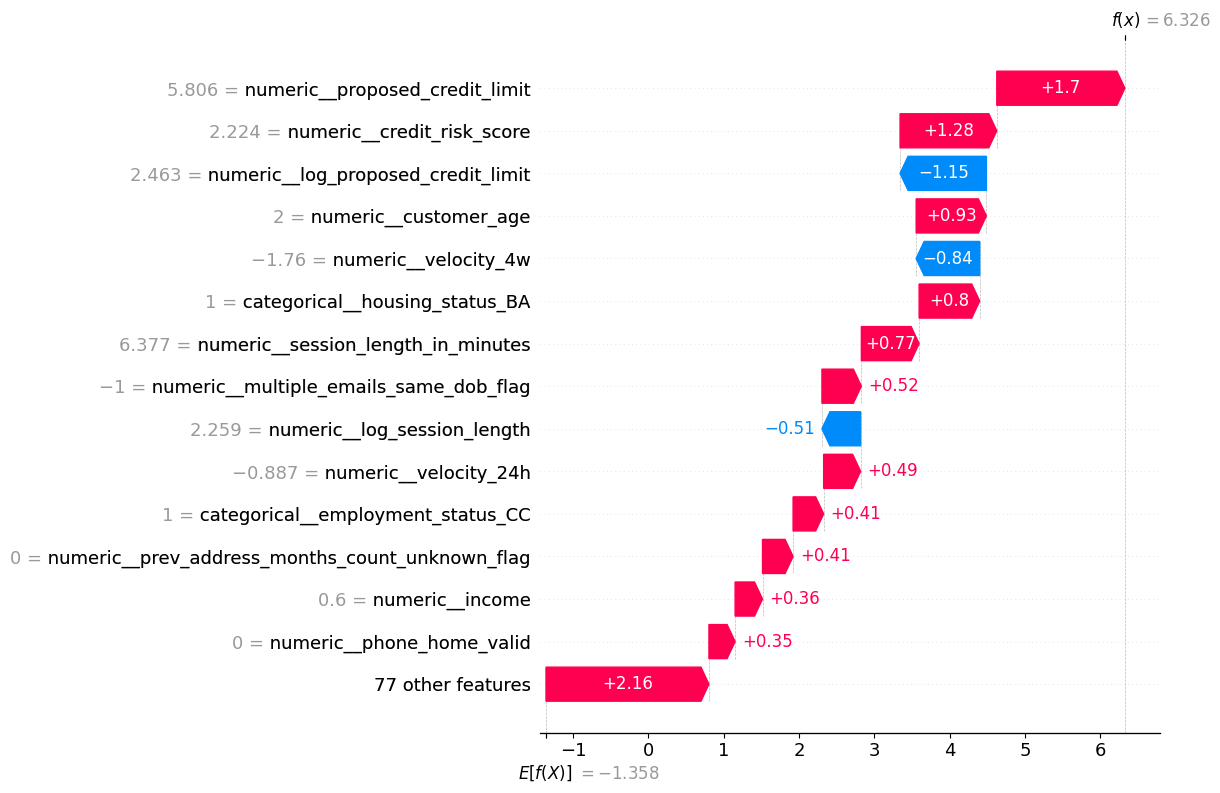


Outcome: False Positive
Predicted probability: 0.9964012587893376


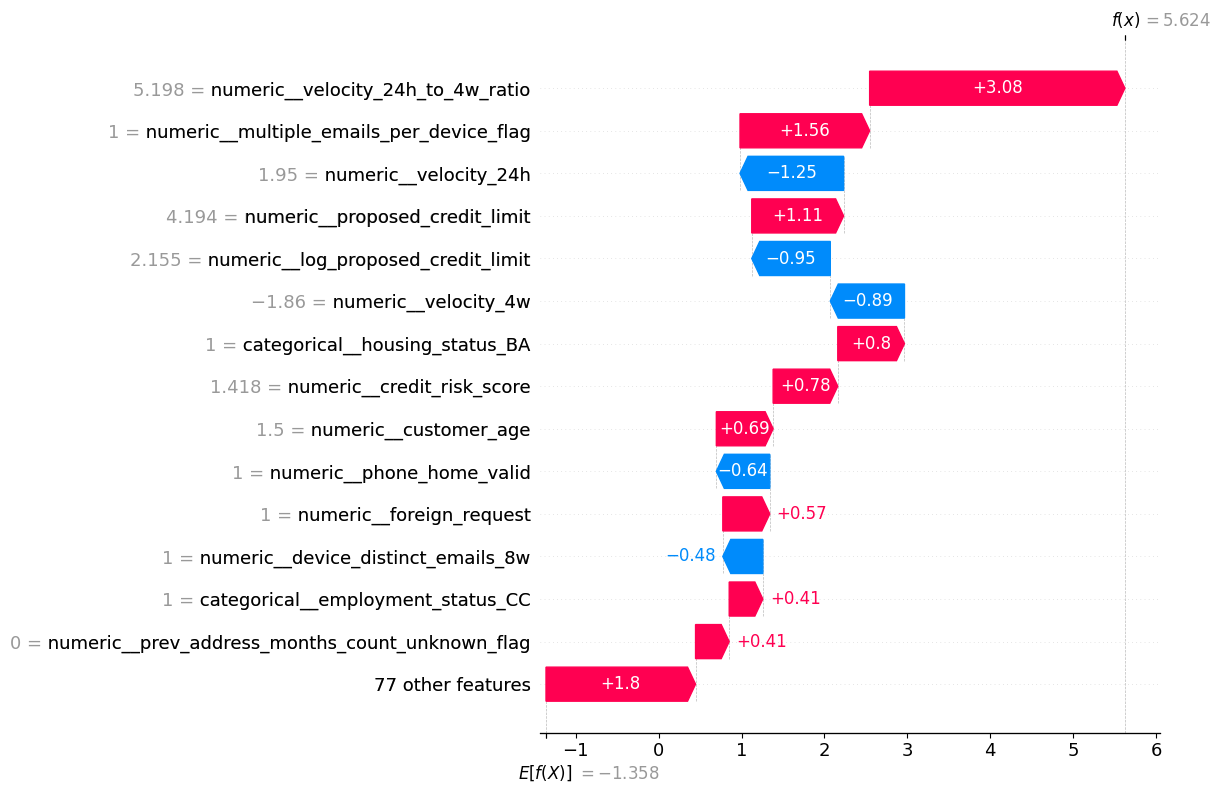


Outcome: False Negative
Predicted probability: 0.6577898355586496


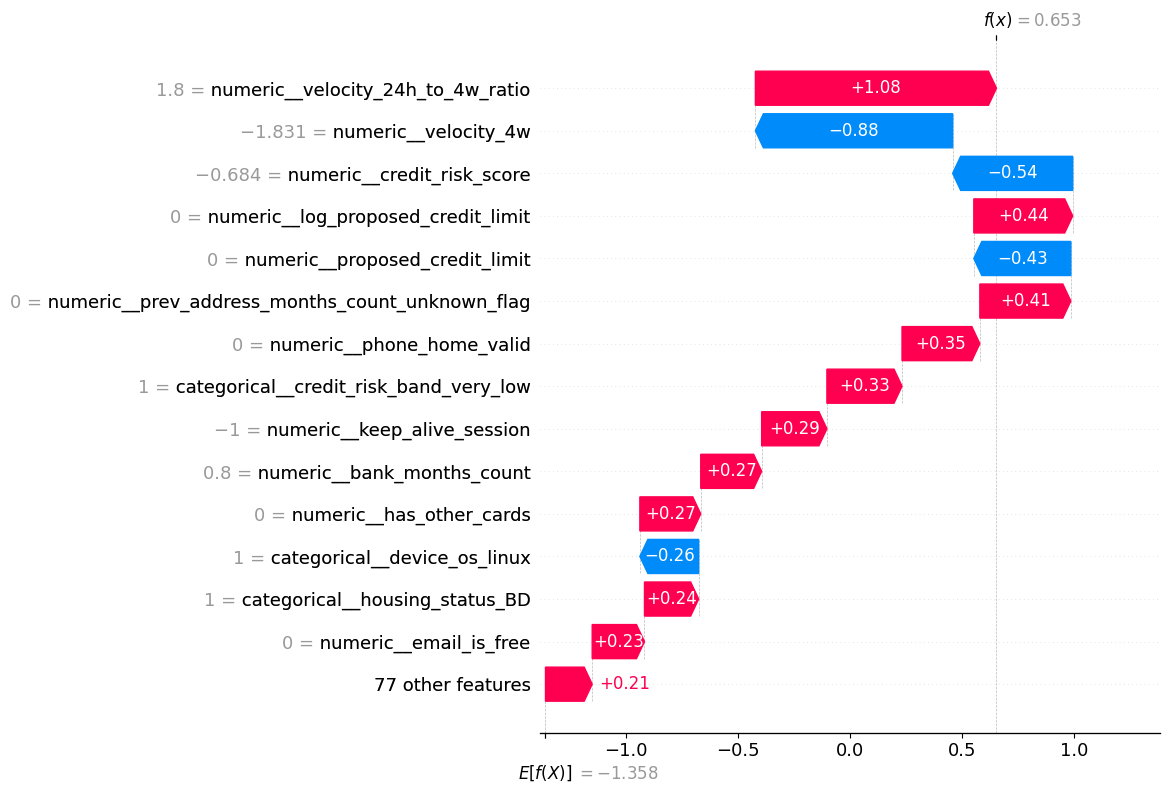


Outcome: True Negative
Predicted probability: 0.6581245312688224


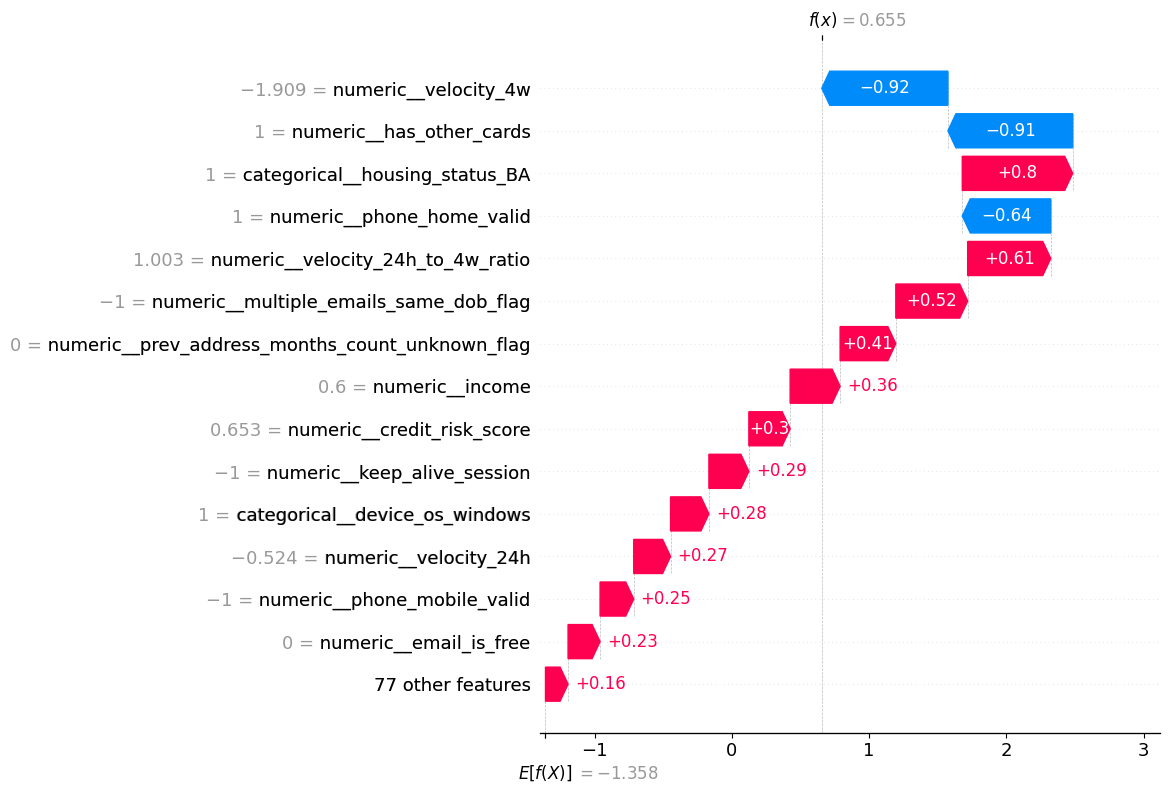

In [ ]:
# Generate SHAP waterfall explanations

selected_positions = list(
    representative_positions.values()
)

selected_rows = X_test.iloc[
    selected_positions
]

selected_transformed = fitted_preprocessor.transform(
    selected_rows
)

if sparse.issparse(selected_transformed):
    selected_for_shap = selected_transformed.toarray()
else:
    selected_for_shap = np.asarray(selected_transformed)

selected_shap_values = shap_explainer(
    selected_for_shap
)

selected_shap_values.feature_names = list(
    transformed_feature_names
)

for explanation_index, outcome_name in enumerate(
    representative_positions.keys()
):
    print("\nOutcome:", outcome_name)
    print(
        "Predicted probability:",
        champion_test_score[
            representative_positions[outcome_name]
        ]
    )

    shap.plots.waterfall(
        selected_shap_values[explanation_index],
        max_display=15
    )

**f. Partial Dependence and ICE Analysis**

Partial Dependence Plots show the model’s average response to a feature. ICE curves show whether the response is consistent across individual records. The plots should be interpreted cautiously because correlated variables can make partial dependence less representative of realistic combinations.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


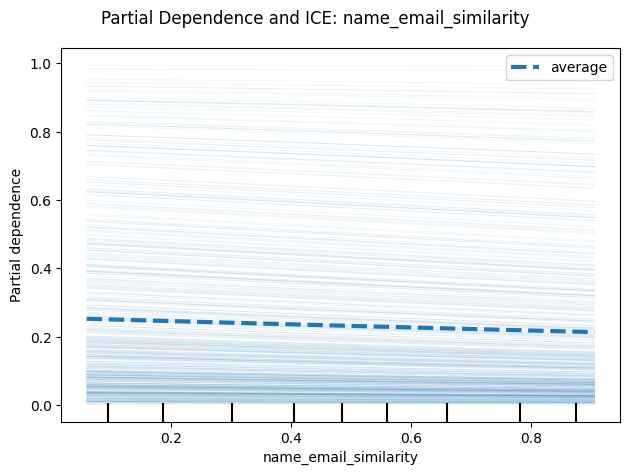

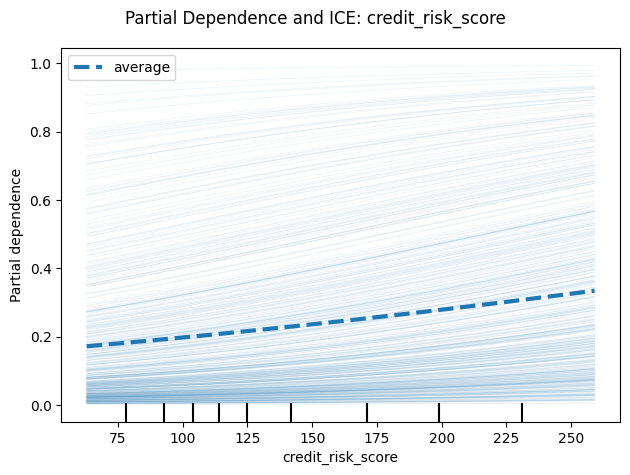

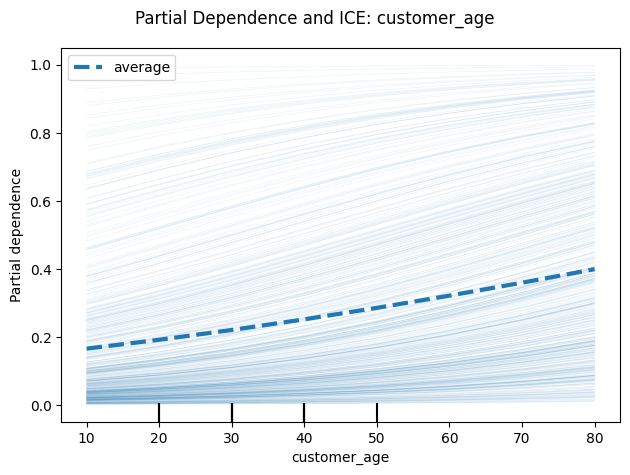

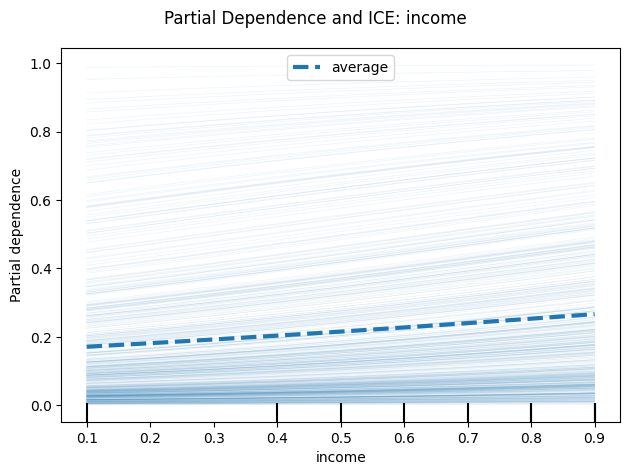

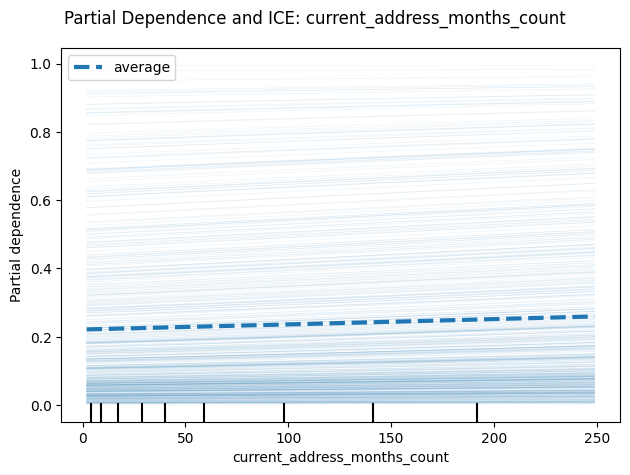

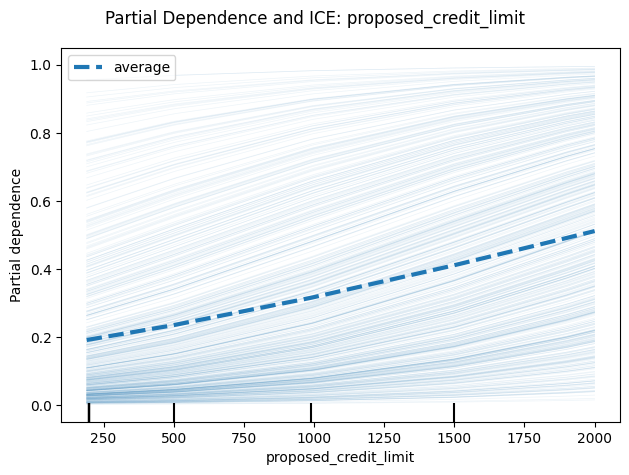

In [ ]:
# PDP and ICE for important original features

from sklearn.inspection import PartialDependenceDisplay

PDP_SAMPLE_SIZE = min(5000, len(X_test))

X_pdp = X_test.sample(
    n=PDP_SAMPLE_SIZE,
    random_state=SEED
)

pdp_features = [
    feature for feature in [
        "name_email_similarity",
        "credit_risk_score",
        "customer_age",
        "income",
        "current_address_months_count",
        "proposed_credit_limit"
    ]
    if feature in X_pdp.columns
]

for feature in pdp_features:

    PartialDependenceDisplay.from_estimator(
        champion_model,
        X_pdp,
        features=[feature],
        kind="both",
        subsample=500,
        random_state=SEED,
        ice_lines_kw={"alpha": 0.08},
        pd_line_kw={"linewidth": 3}
    )

    plt.suptitle(
        f"Partial Dependence and ICE: {feature}"
    )
    plt.tight_layout()
    plt.show()

**g. Limitations Identified**


The first limitation is class imbalance. Fraud prevalence increased from 1.0253% in training to 1.3405% in validation and 1.4746% in the test period. PR-AUC, class weighting, stratified cross-validation, and top-K evaluation were appropriate responses, but changing prevalence may affect probability calibration and operational workload.


The second limitation is threshold transfer. The Base-derived threshold produced an 8.11% positive prediction rate on Base month 7 but approximately a 12.98% positive rate on Variant II month 7. Variant II recall increased, but precision and F1 decreased, the false-positive rate increased by 65.87% relative to Base, and the Brier score worsened. The model’s ranking remained stable, but its fixed operating threshold did not transfer equally well.


The third limitation is synthetic-data generalization. Base and Variant II are controlled variants of the same dataset suite. Stable results across them do not prove that the model will generalize to a live financial institution, new fraud typologies, or customer populations not represented in the suite.

The fourth limitation concerns unavailable protected attributes. Race, gender, ethnicity, disability, and other protected characteristics are not available. The project must not infer them from names, devices, addresses, or behavioral data. Fairness conclusions must therefore be limited to age and available socioeconomic indicators.


The fifth limitation is proxy risk. Age, income, employment status, and housing status are included directly in the model or in engineered features. These variables may improve detection but may also produce unequal review burdens. Their role must be examined through subgroup metrics and feature-ablation analysis.


The sixth limitation is a preprocessing leakage risk found in Step 3. credit_risk_band was created using pd.qcut on the complete Base dataset before the temporal split. Its quantile boundaries therefore used information from validation and test records. Variant II bands were also created independently, making their meaning potentially inconsistent across variants. The raw credit_risk_score is already included, so the safest final approach is to remove credit_risk_band from modeling or create its cut points using training data only.


**h. Sensitivity Test for the Credit-Risk-Band Leakage Risk**

This targeted analysis refits the selected Logistic Regression specification without credit_risk_band. It does not repeat full model selection. It determines whether the reported performance depends materially on the potentially leaked feature.

In [ ]:
# Build a leakage-corrected Logistic Regression candidate

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

LEAKAGE_SENSITIVITY_DROP = [
    "credit_risk_band"
]

X_train_leakage_audit = X_train_full.drop(
    columns=LEAKAGE_SENSITIVITY_DROP,
    errors="ignore"
)

X_valid_leakage_audit = X_valid.drop(
    columns=LEAKAGE_SENSITIVITY_DROP,
    errors="ignore"
)

X_test_leakage_audit = X_test.drop(
    columns=LEAKAGE_SENSITIVITY_DROP,
    errors="ignore"
)

X_variant_leakage_audit = X_variant_test.drop(
    columns=LEAKAGE_SENSITIVITY_DROP,
    errors="ignore"
)

audit_numeric_features = (
    X_train_leakage_audit
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

audit_categorical_features = (
    X_train_leakage_audit
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

try:
    audit_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    audit_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

audit_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    RobustScaler()
                )
            ]),
            audit_numeric_features
        ),
        (
            "categorical",
            Pipeline(steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "encoder",
                    audit_encoder
                )
            ]),
            audit_categorical_features
        )
    ],
    remainder="drop"
)

leakage_corrected_model = Pipeline(steps=[
    (
        "preprocessor",
        audit_preprocessor
    ),
    (
        "model",
        clone(fitted_estimator)
    )
])

leakage_corrected_model.fit(
    X_train_leakage_audit,
    y_train_full
)

leakage_corrected_valid_score = (
    leakage_corrected_model.predict_proba(
        X_valid_leakage_audit
    )[:, 1]
)

leakage_corrected_threshold = (
    threshold_for_review_rate(
        leakage_corrected_valid_score,
        TOP_REVIEW_RATE
    )
)

leakage_corrected_test_score = (
    leakage_corrected_model.predict_proba(
        X_test_leakage_audit
    )[:, 1]
)

leakage_corrected_variant_score = (
    leakage_corrected_model.predict_proba(
        X_variant_leakage_audit
    )[:, 1]
)

In [ ]:
# Compare original and leakage-corrected results

leakage_sensitivity_results = pd.DataFrame([
    {
        "model_version": "Original champion",
        "dataset": "Base month 7",
        **evaluate_binary_classifier(
            y_test,
            champion_test_score,
            champion_threshold
        ),
        **evaluate_top_k(
            y_test,
            champion_test_score,
            TOP_REVIEW_RATE
        )
    },
    {
        "model_version": "Without credit_risk_band",
        "dataset": "Base month 7",
        **evaluate_binary_classifier(
            y_test,
            leakage_corrected_test_score,
            leakage_corrected_threshold
        ),
        **evaluate_top_k(
            y_test,
            leakage_corrected_test_score,
            TOP_REVIEW_RATE
        )
    },
    {
        "model_version": "Original champion",
        "dataset": "Variant II month 7",
        **evaluate_binary_classifier(
            y_variant_test,
            variant_test_score,
            champion_threshold
        ),
        **evaluate_top_k(
            y_variant_test,
            variant_test_score,
            TOP_REVIEW_RATE
        )
    },
    {
        "model_version": "Without credit_risk_band",
        "dataset": "Variant II month 7",
        **evaluate_binary_classifier(
            y_variant_test,
            leakage_corrected_variant_score,
            leakage_corrected_threshold
        ),
        **evaluate_top_k(
            y_variant_test,
            leakage_corrected_variant_score,
            TOP_REVIEW_RATE
        )
    }
])

display(leakage_sensitivity_results)

,model_version,dataset,threshold,accuracy,pr_auc,roc_auc,precision,recall,f1_score,brier_score,...,false_positive_rate,false_negative_rate,predicted_positive_rate,review_rate,applications_reviewed,fraud_captured,total_fraud,recall_at_k,precision_at_k,lift_at_k
0,Original champion,Base month 7,0.658130,0.922648,0.198539,0.890668,0.114067,0.627451,0.193041,0.102045,...,0.072934,0.372549,0.081111,0.1,9685,957,1428,0.670168,0.098813,6.701196
1,Without credit_risk_band,Base month 7,0.660152,0.923681,0.198440,0.889947,0.113745,0.614846,0.191976,0.102231,...,0.071697,0.385154,0.079706,0.1,9685,961,1428,0.672969,0.099226,6.729205
2,Original champion,Variant II month 7,0.658130,0.876634,0.201282,0.889638,0.081483,0.717087,0.146338,0.144208,...,0.120978,0.282913,0.129768,0.1,9685,949,1428,0.664566,0.097987,6.645109
3,Without credit_risk_band,Variant II month 7,0.660152,0.880145,0.200398,0.889759,0.082794,0.707283,0.148235,0.141752,...,0.117268,0.292717,0.125968,0.1,9685,938,1428,0.656863,0.096851,6.568085


**Leakage-sensitivity result.** Removing `credit_risk_band` had negligible effect on ranking performance. Base PR-AUC changed from **0.198539 to 0.198440**, while exact top-10% recall slightly improved from **0.670168 to 0.672969** and precision from **0.098813 to 0.099226**. Variant II PR-AUC changed from **0.201282 to 0.200398**, while its Brier score improved from **0.144208 to 0.141752**. Because the band adds little predictive value and was derived using dataset-wide quantiles, the leakage-corrected specification without `credit_risk_band` is the safer candidate for a final production retraining.

**i. Probability Calibration and Threshold Stability**

Because the notebook showed stable ranking but weaker fixed-threshold transfer to Variant II, calibration must be explicitly assessed.

In [ ]:
# Calibration analysis

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def expected_calibration_error(
    y_true,
    y_score,
    n_bins=10
):
    calibration_data = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(y_score)
    })

    calibration_data["bin"] = pd.cut(
        calibration_data["score"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True
    )

    grouped = calibration_data.groupby(
        "bin",
        observed=True
    ).agg(
        count=("actual", "size"),
        observed_rate=("actual", "mean"),
        average_score=("score", "mean")
    )

    grouped["weight"] = (
        grouped["count"]
        / grouped["count"].sum()
    )

    return (
        grouped["weight"]
        * (
            grouped["observed_rate"]
            - grouped["average_score"]
        ).abs()
    ).sum()


calibration_summary = pd.DataFrame([
    {
        "dataset": "Base month 7",
        "brier_score": brier_score_loss(
            y_test,
            champion_test_score
        ),
        "expected_calibration_error": (
            expected_calibration_error(
                y_test,
                champion_test_score
            )
        ),
        "mean_predicted_probability": (
            champion_test_score.mean()
        ),
        "observed_fraud_rate": y_test.mean()
    },
    {
        "dataset": "Variant II month 7",
        "brier_score": brier_score_loss(
            y_variant_test,
            variant_test_score
        ),
        "expected_calibration_error": (
            expected_calibration_error(
                y_variant_test,
                variant_test_score
            )
        ),
        "mean_predicted_probability": (
            variant_test_score.mean()
        ),
        "observed_fraud_rate": y_variant_test.mean()
    }
])

display(calibration_summary)

,dataset,brier_score,expected_calibration_error,mean_predicted_probability,observed_fraud_rate
0,Base month 7,0.102045,0.215144,0.229890,0.014746
1,Variant II month 7,0.144208,0.271248,0.285994,0.014746


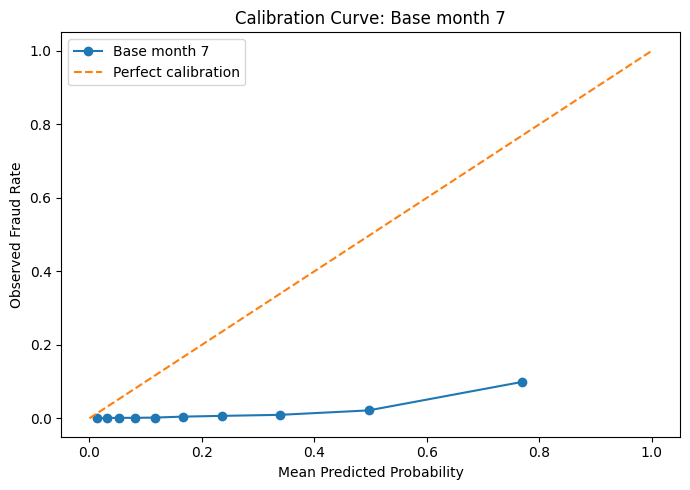

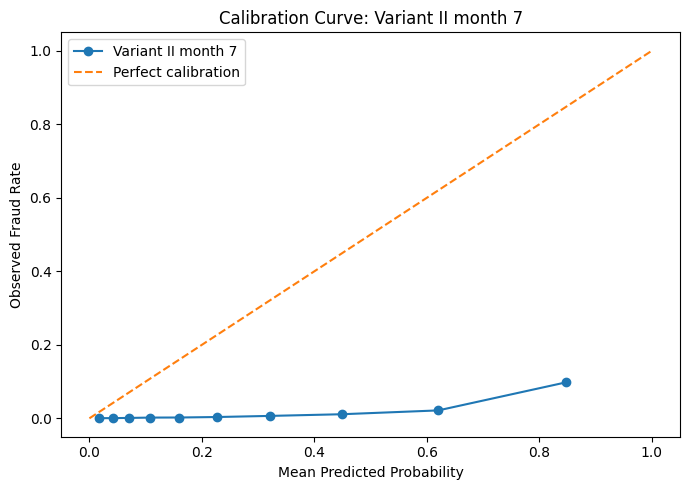

In [ ]:
# Calibration curves

for dataset_name, actual, score in [
    (
        "Base month 7",
        y_test,
        champion_test_score
    ),
    (
        "Variant II month 7",
        y_variant_test,
        variant_test_score
    )
]:

    observed_probability, predicted_probability = (
        calibration_curve(
            actual,
            score,
            n_bins=10,
            strategy="quantile"
        )
    )

    plt.figure(figsize=(7, 5))
    plt.plot(
        predicted_probability,
        observed_probability,
        marker="o",
        label=dataset_name
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )
    plt.title(
        f"Calibration Curve: {dataset_name}"
    )
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Fraud Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Calibration result.** The champion ranks applications effectively but its raw probabilities are not calibrated. Mean predicted probability was **22.99%** on Base and **28.60%** on Variant II, while observed fraud prevalence was only **1.47%** in both. Expected calibration error increased from **0.215** on Base to **0.271** on Variant II, and the Brier score worsened from **0.102** to **0.144**. This is consistent with the use of balanced class weights: the scores are useful for ordering risk but should not be interpreted as literal fraud probabilities without post-hoc calibration.

**j. Create Fairness Audit Groups**

The primary audit attributes are age and income. Employment and housing are included as supplemental socioeconomic proxy groups. These analyses do not replace an audit using legally governed protected characteristics.

In [ ]:
# Create fairness audit groups

def create_fairness_groups(X):
    groups = pd.DataFrame(index=X.index)

    if "customer_age_group" in X.columns:
        groups["age_group"] = (
            X["customer_age_group"]
            .astype("object")
            .astype(str)
        )
    elif "customer_age" in X.columns:
        groups["age_group"] = pd.cut(
            X["customer_age"],
            bins=[
                -np.inf,
                29,
                39,
                49,
                59,
                np.inf
            ],
            labels=[
                "29 and below",
                "30-39",
                "40-49",
                "50-59",
                "60 and above"
            ]
        ).astype(str)

    if "income" in X.columns:
        groups["income_group"] = pd.cut(
            X["income"],
            bins=[
                -np.inf,
                0.30,
                0.60,
                np.inf
            ],
            labels=[
                "Lower income band",
                "Middle income band",
                "Higher income band"
            ],
            include_lowest=True
        ).astype(str)

    if "employment_status" in X.columns:
        groups["employment_status"] = (
            X["employment_status"].astype(str)
        )

    if "housing_status" in X.columns:
        groups["housing_status"] = (
            X["housing_status"].astype(str)
        )

    return groups.reset_index(drop=True)


training_fairness_groups = create_fairness_groups(
    X_train_full
)

validation_fairness_groups = create_fairness_groups(
    X_valid
)

test_fairness_groups = create_fairness_groups(
    X_test
)

display(test_fairness_groups.head())

,age_group,income_group,employment_status,housing_status
0,30-39,Higher income band,CA,BA
1,20-29,Higher income band,CB,BA
2,30-39,Lower income band,CF,BB
3,20-29,Lower income band,CA,BB
4,<20,Middle income band,CA,BE


**k. Group-Level Performance and Fairness Metrics**

The group analysis reports selection rate, prevalence, recall or true-positive rate, false-positive rate, false-negative rate, precision, PR-AUC, and Brier score. Reporting prevalence is important because different selection rates may partly reflect different observed fraud rates rather than model behavior alone.

In [ ]:
# Calculate subgroup performance metrics

from sklearn.metrics import (
    confusion_matrix,
    average_precision_score,
    brier_score_loss
)

def calculate_group_metrics(
    y_true,
    y_score,
    y_pred,
    sensitive_group,
    minimum_group_size=500,
    minimum_fraud_cases=30
):

    audit_data = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(y_score),
        "prediction": np.asarray(y_pred),
        "group": np.asarray(sensitive_group)
    })

    group_results = []

    for group_name, group_data in audit_data.groupby(
        "group",
        dropna=False
    ):

        tn, fp, fn, tp = confusion_matrix(
            group_data["actual"],
            group_data["prediction"],
            labels=[0, 1]
        ).ravel()

        group_count = len(group_data)
        fraud_count = int(group_data["actual"].sum())

        tpr = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        fnr = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else np.nan
        )

        if group_data["actual"].nunique() == 2:
            group_pr_auc = average_precision_score(
                group_data["actual"],
                group_data["score"]
            )
        else:
            group_pr_auc = np.nan

        if (
            group_count >= minimum_group_size
            and fraud_count >= minimum_fraud_cases
        ):
            stability_flag = "Adequate for primary interpretation"
        else:
            stability_flag = "Interpret cautiously"

        group_results.append({
            "group": group_name,
            "count": group_count,
            "fraud_count": fraud_count,
            "fraud_prevalence": (
                group_data["actual"].mean()
            ),
            "selection_rate": (
                group_data["prediction"].mean()
            ),
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
            "false_negative_rate": fnr,
            "precision": precision,
            "pr_auc": group_pr_auc,
            "average_predicted_score": (
                group_data["score"].mean()
            ),
            "brier_score": brier_score_loss(
                group_data["actual"],
                group_data["score"]
            ),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "true_negatives": int(tn),
            "false_negatives": int(fn),
            "stability_flag": stability_flag
        })

    return pd.DataFrame(group_results)

**l. Calculate Demographic Parity, Disparate Impact and Equalized Odds**

Demographic parity difference is calculated as the highest minus lowest group selection rate. Disparate impact is calculated as the lowest divided by the highest selection rate. Equal opportunity difference is the range of group true-positive rates. Equalized odds difference is the larger of the true-positive-rate and false-positive-rate ranges.

These are diagnostic measures, not automatic legal pass-or-fail rules.

In [ ]:
# Calculate aggregate fairness gaps

def metric_range(series):
    valid_values = pd.Series(series).dropna()

    if valid_values.empty:
        return np.nan

    return valid_values.max() - valid_values.min()


def minimum_to_maximum_ratio(series):
    valid_values = pd.Series(series).dropna()

    if valid_values.empty or valid_values.max() == 0:
        return np.nan

    return valid_values.min() / valid_values.max()


def summarize_fairness_gaps(
    group_metrics,
    attribute_name
):

    tpr_difference = metric_range(
        group_metrics["true_positive_rate"]
    )

    fpr_difference = metric_range(
        group_metrics["false_positive_rate"]
    )

    valid_equalized_odds_components = [
        value
        for value in [
            tpr_difference,
            fpr_difference
        ]
        if not pd.isna(value)
    ]

    equalized_odds_difference = (
        max(valid_equalized_odds_components)
        if valid_equalized_odds_components
        else np.nan
    )

    return {
        "attribute": attribute_name,
        "demographic_parity_difference": (
            metric_range(
                group_metrics["selection_rate"]
            )
        ),
        "disparate_impact_ratio": (
            minimum_to_maximum_ratio(
                group_metrics["selection_rate"]
            )
        ),
        "equal_opportunity_difference": (
            tpr_difference
        ),
        "false_positive_rate_difference": (
            fpr_difference
        ),
        "equalized_odds_difference": (
            equalized_odds_difference
        ),
        "fraud_prevalence_difference": (
            metric_range(
                group_metrics["fraud_prevalence"]
            )
        ),
        "pr_auc_difference": (
            metric_range(
                group_metrics["pr_auc"]
            )
        ),
        "brier_score_difference": (
            metric_range(
                group_metrics["brier_score"]
            )
        )
    }

In [ ]:
# Run fairness audit on Base month 7

base_test_predictions = (
    champion_test_score >= champion_threshold
).astype(int)

fairness_group_tables = {}
fairness_gap_rows = []

for attribute in test_fairness_groups.columns:

    group_metrics = calculate_group_metrics(
        y_true=y_test,
        y_score=champion_test_score,
        y_pred=base_test_predictions,
        sensitive_group=(
            test_fairness_groups[attribute]
        )
    )

    fairness_group_tables[attribute] = group_metrics

    fairness_gap_rows.append(
        summarize_fairness_gaps(
            group_metrics,
            attribute
        )
    )

    print("\n" + "=" * 80)
    print("Audit attribute:", attribute)
    display(group_metrics)


fairness_gap_summary = pd.DataFrame(
    fairness_gap_rows
)

display(fairness_gap_summary)


Audit attribute: age_group


,group,count,fraud_count,fraud_prevalence,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,pr_auc,average_predicted_score,brier_score,true_positives,false_positives,true_negatives,false_negatives,stability_flag
0,20-29,32363,405,0.012514,0.064796,0.535802,0.058827,0.464198,0.103481,0.154121,0.213831,0.090836,217,1880,30078,188,Adequate for primary interpretation
1,30-39,27860,436,0.015650,0.092319,0.644495,0.083540,0.355505,0.109253,0.186918,0.251537,0.114314,281,2291,25133,155,Adequate for primary interpretation
2,40-49,9725,256,0.026324,0.171208,0.781250,0.154715,0.218750,0.120120,0.257330,0.331986,0.172501,200,1465,8004,56,Adequate for primary interpretation
3,50-59,2501,131,0.052379,0.265894,0.832061,0.234599,0.167939,0.163910,0.338212,0.425470,0.236675,109,556,1814,22,Adequate for primary interpretation
4,60-69,364,25,0.068681,0.335165,0.880000,0.294985,0.120000,0.180328,0.359146,0.469355,0.271005,22,100,239,3,Interpret cautiously
5,70+,77,6,0.077922,0.363636,0.833333,0.323944,0.166667,0.178571,0.533482,0.544332,0.321559,5,23,48,1,Interpret cautiously
6,<20,23953,169,0.007055,0.029474,0.366864,0.027077,0.633136,0.087819,0.097033,0.159887,0.056983,62,644,23140,107,Adequate for primary interpretation



Audit attribute: income_group


,group,count,fraud_count,fraud_prevalence,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,pr_auc,average_predicted_score,brier_score,true_positives,false_positives,true_negatives,false_negatives,stability_flag
0,Higher income band,64414,1158,0.017977,0.101934,0.655440,0.091802,0.344560,0.115595,0.206484,0.260983,0.121692,759,5807,57449,399,Adequate for primary interpretation
1,Lower income band,20645,149,0.007217,0.031678,0.483221,0.028396,0.516779,0.110092,0.150500,0.154511,0.055005,72,582,19914,77,Adequate for primary interpretation
2,Middle income band,11784,121,0.010268,0.053887,0.537190,0.048873,0.462810,0.102362,0.197214,0.191986,0.077063,65,570,11093,56,Adequate for primary interpretation



Audit attribute: employment_status


,group,count,fraud_count,fraud_prevalence,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,pr_auc,average_predicted_score,brier_score,true_positives,false_positives,true_negatives,false_negatives,stability_flag
0,CA,74882,1195,0.015958,0.089207,0.646862,0.080163,0.353138,0.115719,0.206750,0.244117,0.110233,773,5907,67780,422,Adequate for primary interpretation
1,CB,11275,115,0.010200,0.055698,0.460870,0.051523,0.539130,0.084395,0.123375,0.200216,0.081962,53,575,10585,62,Adequate for primary interpretation
2,CC,2265,84,0.037086,0.204415,0.761905,0.182944,0.238095,0.138229,0.264725,0.372694,0.198921,64,399,1782,20,Adequate for primary interpretation
3,CD,2513,12,0.004775,0.017907,0.333333,0.016393,0.666667,0.088889,0.132124,0.140205,0.045265,4,41,2460,8,Interpret cautiously
4,CE,2252,9,0.003996,0.005329,0.000000,0.005350,1.000000,0.000000,0.034986,0.092425,0.024053,0,12,2231,9,Interpret cautiously
5,CF,3618,11,0.003040,0.005804,0.090909,0.005545,0.909091,0.047619,0.025665,0.086023,0.022144,1,20,3587,10,Interpret cautiously
6,CG,38,2,0.052632,0.157895,0.500000,0.138889,0.500000,0.166667,0.340909,0.262990,0.136006,1,5,31,1,Interpret cautiously



Audit attribute: housing_status


,group,count,fraud_count,fraud_prevalence,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,pr_auc,average_predicted_score,brier_score,true_positives,false_positives,true_negatives,false_negatives,stability_flag
0,BA,19182,899,0.046867,0.290898,0.777531,0.266969,0.222469,0.125269,0.253083,0.465180,0.266048,699,4881,13402,200,Adequate for primary interpretation
1,BB,23213,166,0.007151,0.029983,0.415663,0.027205,0.584337,0.099138,0.116464,0.173448,0.062367,69,627,22420,97,Adequate for primary interpretation
2,BC,37502,266,0.007093,0.030452,0.364662,0.028064,0.635338,0.084939,0.108932,0.173711,0.062956,97,1045,36191,169,Adequate for primary interpretation
3,BD,4478,42,0.009379,0.063198,0.547619,0.058611,0.452381,0.081272,0.119451,0.235659,0.098532,23,260,4176,19,Adequate for primary interpretation
4,BE,12327,54,0.004381,0.012250,0.129630,0.011733,0.870370,0.046358,0.042458,0.139726,0.042399,7,144,12129,47,Adequate for primary interpretation
5,BF,135,1,0.007407,0.022222,1.000000,0.014925,0.000000,0.333333,1.000000,0.156788,0.046929,1,2,132,0,Interpret cautiously
6,BG,6,0,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,0.089783,0.012281,0,0,6,0,Interpret cautiously


,attribute,demographic_parity_difference,disparate_impact_ratio,equal_opportunity_difference,false_positive_rate_difference,equalized_odds_difference,fraud_prevalence_difference,pr_auc_difference,brier_score_difference
0,age_group,0.334162,0.081055,0.513136,0.296867,0.513136,0.070867,0.436449,0.264576
1,income_group,0.070256,0.310772,0.172219,0.063406,0.172219,0.010760,0.055984,0.066687
2,employment_status,0.199086,0.026068,0.761905,0.177594,0.761905,0.049591,0.315245,0.176777
3,housing_status,0.290898,0.000000,0.870370,0.266969,0.870370,0.046867,0.957542,0.253767


**Fairness-audit result.** Material group differences were observed. For age, selection increased from **2.95%** for applicants under 20 to **26.59%** for ages 50-59, while true-positive rate rose from **36.69%** to **83.21%**. The age demographic-parity difference was **0.334**, disparate-impact ratio **0.081**, and equalized-odds difference **0.513**. Income disparities were smaller but still meaningful: the higher-income band had a **10.19%** selection rate and **65.54%** true-positive rate versus **3.17%** and **48.32%** in the lower-income band; the income disparate-impact ratio was **0.311**. Employment and housing showed even larger gaps, although several categories had small fraud counts and require cautious interpretation. Observed base-rate differences explain part, but not all, of the outcome gaps.

**n. Visualize Primary Fairness Results**

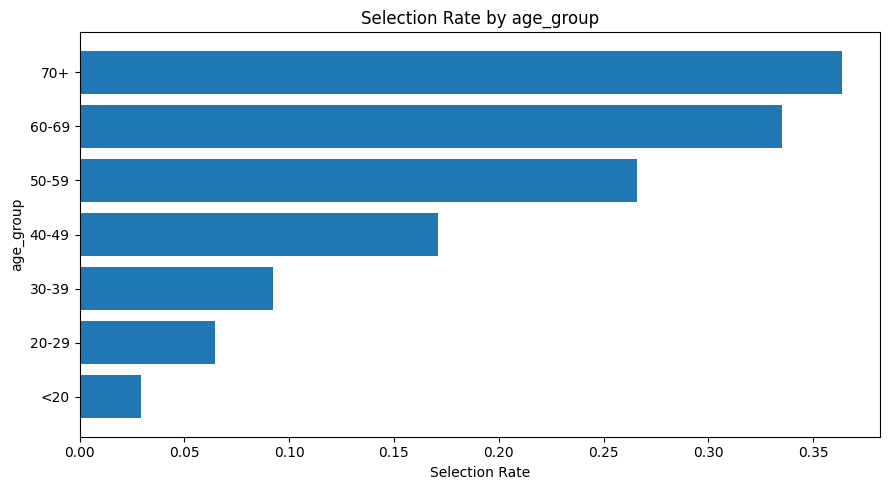

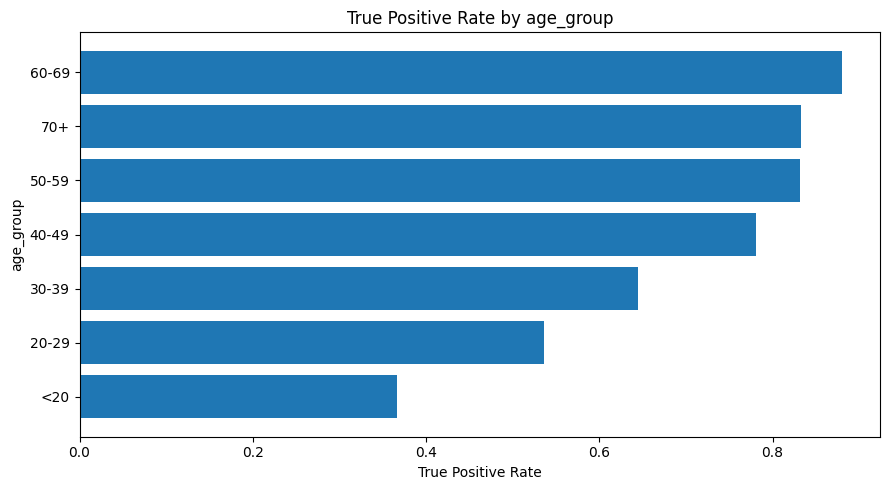

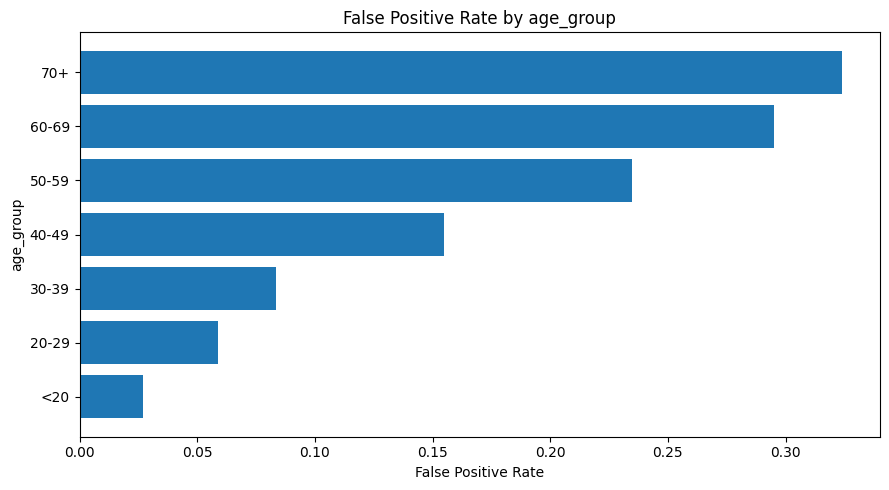

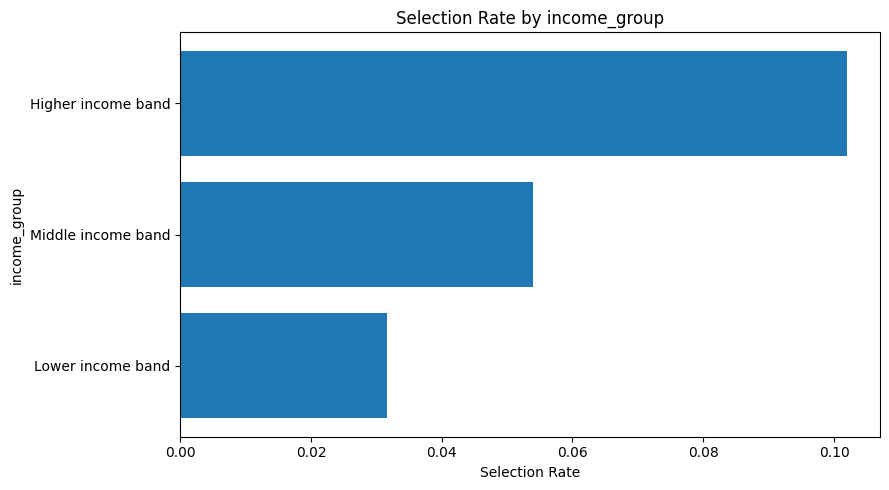

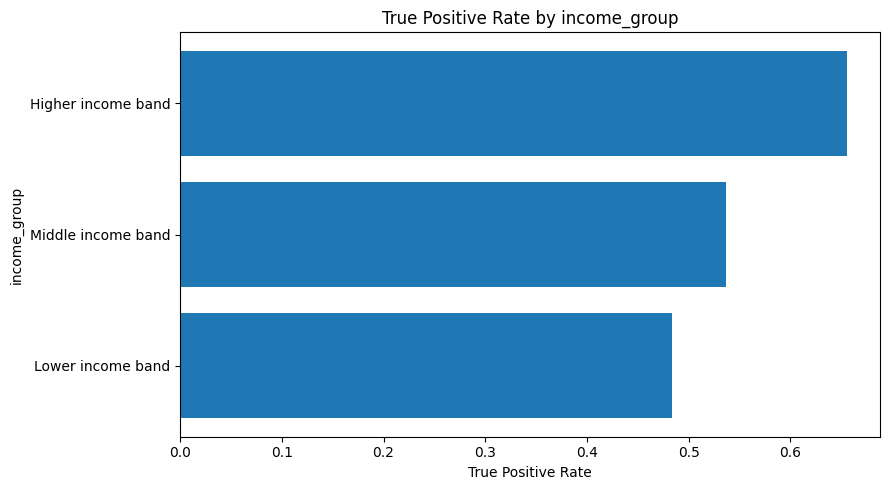

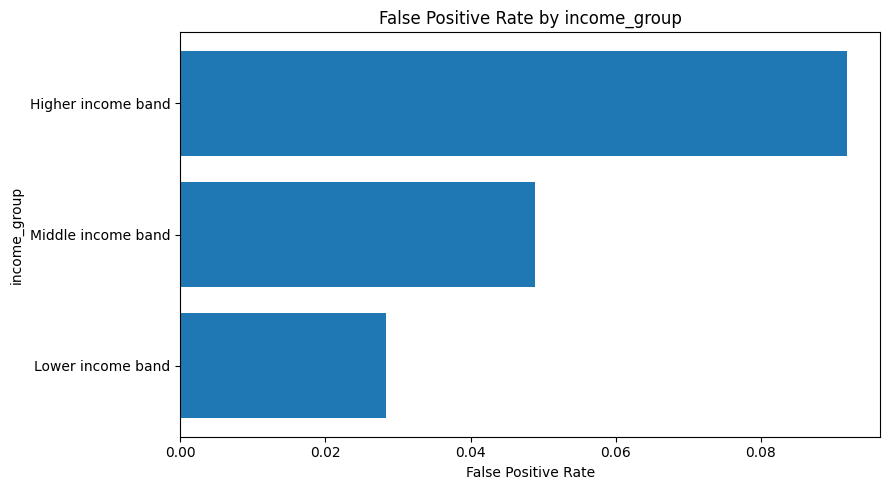

In [ ]:
# Visualize age and income fairness metrics

for attribute in [
    "age_group",
    "income_group"
]:

    if attribute not in fairness_group_tables:
        continue

    group_table = fairness_group_tables[attribute]

    for metric, title in [
        (
            "selection_rate",
            "Selection Rate"
        ),
        (
            "true_positive_rate",
            "True Positive Rate"
        ),
        (
            "false_positive_rate",
            "False Positive Rate"
        )
    ]:

        chart_data = group_table.sort_values(metric)

        plt.figure(figsize=(9, 5))
        plt.barh(
            chart_data["group"].astype(str),
            chart_data[metric]
        )
        plt.title(
            f"{title} by {attribute}"
        )
        plt.xlabel(title)
        plt.ylabel(attribute)
        plt.tight_layout()
        plt.show()

**o. Review-Rate and Threshold Sensitivity**

The notebook showed that a fixed threshold did not produce the same review workload across Base and Variant II. This analysis evaluates 5%, 10%, 15%, and 20% review policies using thresholds derived only from month 6 validation data.

In [ ]:
# Threshold and fairness sensitivity

review_rate_scenarios = [
    0.05,
    0.10,
    0.15,
    0.20
]

threshold_sensitivity_rows = []

for review_rate in review_rate_scenarios:

    scenario_threshold = threshold_for_review_rate(
        champion_valid_score,
        review_rate
    )

    scenario_test_prediction = (
        champion_test_score >= scenario_threshold
    ).astype(int)

    scenario_technical = evaluate_binary_classifier(
        y_test,
        champion_test_score,
        scenario_threshold
    )

    scenario_top_k = evaluate_top_k(
        y_test,
        champion_test_score,
        review_rate
    )

    scenario_business = evaluate_business_kpis(
        y_test,
        champion_test_score,
        review_rate=review_rate,
        **BUSINESS_ASSUMPTIONS
    )

    age_metrics = calculate_group_metrics(
        y_true=y_test,
        y_score=champion_test_score,
        y_pred=scenario_test_prediction,
        sensitive_group=(
            test_fairness_groups["age_group"]
        )
    )

    income_metrics = calculate_group_metrics(
        y_true=y_test,
        y_score=champion_test_score,
        y_pred=scenario_test_prediction,
        sensitive_group=(
            test_fairness_groups["income_group"]
        )
    )

    age_gaps = summarize_fairness_gaps(
        age_metrics,
        "age_group"
    )

    income_gaps = summarize_fairness_gaps(
        income_metrics,
        "income_group"
    )

    threshold_sensitivity_rows.append({
        "target_review_rate": review_rate,
        "validation_derived_threshold": (
            scenario_threshold
        ),
        "actual_test_selection_rate": (
            scenario_technical[
                "predicted_positive_rate"
            ]
        ),
        "overall_recall": (
            scenario_technical["recall"]
        ),
        "overall_precision": (
            scenario_technical["precision"]
        ),
        "recall_at_k": (
            scenario_top_k["recall_at_k"]
        ),
        "precision_at_k": (
            scenario_top_k["precision_at_k"]
        ),
        "estimated_net_benefit": (
            scenario_business[
                "estimated_net_benefit"
            ]
        ),
        "age_equalized_odds_difference": (
            age_gaps[
                "equalized_odds_difference"
            ]
        ),
        "income_equalized_odds_difference": (
            income_gaps[
                "equalized_odds_difference"
            ]
        ),
        "age_disparate_impact_ratio": (
            age_gaps[
                "disparate_impact_ratio"
            ]
        ),
        "income_disparate_impact_ratio": (
            income_gaps[
                "disparate_impact_ratio"
            ]
        )
    })


threshold_sensitivity_results = pd.DataFrame(
    threshold_sensitivity_rows
)

display(threshold_sensitivity_results)

,target_review_rate,validation_derived_threshold,actual_test_selection_rate,overall_recall,overall_precision,recall_at_k,precision_at_k,estimated_net_benefit,age_equalized_odds_difference,income_equalized_odds_difference,age_disparate_impact_ratio,income_disparate_impact_ratio
0,0.05,0.793884,0.040024,0.465686,0.171569,0.514006,0.151559,5828450.0,0.649901,0.196926,0.043576,0.249832
1,0.10,0.658130,0.081111,0.627451,0.114067,0.670168,0.098813,6419500.0,0.513136,0.172219,0.081055,0.310772
2,0.15,0.548891,0.123003,0.715686,0.085796,0.759804,0.074689,6036800.0,0.388876,0.138436,0.118390,0.342695
3,0.20,0.462051,0.166114,0.778711,0.069124,0.816527,0.060199,5172350.0,0.486101,0.118210,0.138300,0.385831


**Threshold-sensitivity result.** The 10% policy produced the highest illustrative net benefit (**6.42 million**) and captured **67.02%** of fraud in the exact top-10% queue. A 5% policy improved precision to **17.16%** but reduced fixed-threshold recall to **46.57%**. A 15% policy increased fixed-threshold recall to **71.57%** and reduced the age equalized-odds gap to **0.389**, but lowered net benefit to **6.04 million**. At 20%, recall increased further while precision and net benefit declined. The results show that the operating threshold is a governance decision involving fraud capture, analyst capacity, customer burden, fairness, and financial value.

**p. Reweighting Mitigation Experiment**

Reweighting is evaluated as a feasible model-level mitigation. The experiment gives additional influence to underrepresented age-income intersections while retaining balanced treatment of the fraud and legitimate classes.

The mitigation is selected using validation results only. The final test set should not be used to decide whether reweighting is adopted.

In [ ]:
# Build age-income intersection groups

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone

def create_age_income_intersection(X):
    groups = create_fairness_groups(X)

    return (
        groups["age_group"].astype(str)
        + " | "
        + groups["income_group"].astype(str)
    )


training_intersection = create_age_income_intersection(
    X_train_full
)

group_frequency = training_intersection.value_counts()

group_weight = training_intersection.map(
    lambda group_name: (
        len(training_intersection)
        / (
            len(group_frequency)
            * group_frequency[group_name]
        )
    )
).to_numpy()

class_balance_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train_full
)

training_sample_weight = (
    group_weight
    * class_balance_weight
)

training_sample_weight = (
    training_sample_weight
    / training_sample_weight.mean()
)

training_sample_weight = np.clip(
    training_sample_weight,
    0.25,
    10.0
)

pd.Series(
    training_sample_weight
).describe()

,0
count,794989.000000
mean,0.478701
std,1.165703
min,0.250000
25%,0.250000
50%,0.250000
75%,0.296694
max,10.000000


In [ ]:
# Fit reweighted Logistic Regression

reweighted_model = clone(
    champion_model
)

# Class imbalance is now handled through sample weights.
reweighted_model.set_params(
    model__class_weight=None
)

reweighted_model.fit(
    X_train_full,
    y_train_full,
    model__sample_weight=training_sample_weight
)

reweighted_validation_score = (
    reweighted_model.predict_proba(
        X_valid
    )[:, 1]
)

reweighted_validation_threshold = (
    threshold_for_review_rate(
        reweighted_validation_score,
        TOP_REVIEW_RATE
    )
)

reweighted_validation_prediction = (
    reweighted_validation_score
    >= reweighted_validation_threshold
).astype(int)

**q. Compare the Original and Reweighted Candidates**

In [ ]:
# Compare validation technical performance

original_validation_prediction = (
    champion_valid_score
    >= champion_threshold
).astype(int)

mitigation_performance_comparison = pd.DataFrame([
    {
        "model_version": "Original champion",
        **evaluate_binary_classifier(
            y_valid,
            champion_valid_score,
            champion_threshold
        ),
        **evaluate_top_k(
            y_valid,
            champion_valid_score,
            TOP_REVIEW_RATE
        )
    },
    {
        "model_version": "Reweighted candidate",
        **evaluate_binary_classifier(
            y_valid,
            reweighted_validation_score,
            reweighted_validation_threshold
        ),
        **evaluate_top_k(
            y_valid,
            reweighted_validation_score,
            TOP_REVIEW_RATE
        )
    }
])

display(mitigation_performance_comparison)

,model_version,threshold,accuracy,pr_auc,roc_auc,precision,recall,f1_score,brier_score,true_positives,...,false_positive_rate,false_negative_rate,predicted_positive_rate,review_rate,applications_reviewed,fraud_captured,total_fraud,recall_at_k,precision_at_k,lift_at_k
0,Original champion,0.658130,0.903936,0.165378,0.885377,0.086715,0.646897,0.152931,0.122048,938,...,0.092571,0.353103,0.100002,0.1,10817,938,1450,0.646897,0.086715,6.468846
1,Reweighted candidate,0.394126,0.903086,0.147608,0.871439,0.082463,0.615172,0.145431,0.052298,892,...,0.093002,0.384828,0.100002,0.1,10817,892,1450,0.615172,0.082463,6.151610


In [ ]:
# Compare validation fairness gaps

mitigation_fairness_rows = []

for model_version, score, prediction in [
    (
        "Original champion",
        champion_valid_score,
        original_validation_prediction
    ),
    (
        "Reweighted candidate",
        reweighted_validation_score,
        reweighted_validation_prediction
    )
]:

    for attribute in [
        "age_group",
        "income_group"
    ]:

        group_metrics = calculate_group_metrics(
            y_true=y_valid,
            y_score=score,
            y_pred=prediction,
            sensitive_group=(
                validation_fairness_groups[
                    attribute
                ]
            )
        )

        gap_metrics = summarize_fairness_gaps(
            group_metrics,
            attribute
        )

        mitigation_fairness_rows.append({
            "model_version": model_version,
            **gap_metrics
        })


mitigation_fairness_comparison = pd.DataFrame(
    mitigation_fairness_rows
)

display(mitigation_fairness_comparison)

,model_version,attribute,demographic_parity_difference,disparate_impact_ratio,equal_opportunity_difference,false_positive_rate_difference,equalized_odds_difference,fraud_prevalence_difference,pr_auc_difference,brier_score_difference
0,Original champion,age_group,0.332383,0.096079,0.567901,0.311209,0.567901,0.038208,0.203380,0.241956
1,Original champion,income_group,0.084509,0.323409,0.221666,0.078487,0.221666,0.008742,0.082545,0.075609
2,Reweighted candidate,age_group,0.180144,0.024288,0.729947,0.166884,0.729947,0.038208,0.211259,0.059876
3,Reweighted candidate,income_group,0.107248,0.185359,0.304731,0.100991,0.304731,0.008742,0.067720,0.047343


**Mitigation result.** The tested age-income reweighting strategy was not adopted. It reduced validation PR-AUC from **0.165378 to 0.147608**, recall from **64.69% to 61.52%**, and top-10% lift from **6.47 to 6.15**. Although age demographic-parity difference improved from **0.332 to 0.180** and the age false-positive-rate gap narrowed, age equal-opportunity difference worsened from **0.568 to 0.730** and the disparate-impact ratio fell from **0.096 to 0.024**. Income fairness measures also generally worsened. This experiment demonstrates that mitigation must be judged across multiple technical and fairness metrics rather than a single parity measure.

**r. Governance and Operational Mitigations**

The model should remain a human-supervised prioritization tool. Applications should not be rejected solely because their score exceeds the threshold. Analysts should receive understandable reason codes based on the dominant coefficient or SHAP contributions and should have access to supporting application information.


Thresholds should be reviewed periodically because the notebook showed that an unchanged threshold produced materially different false-positive rates and workloads across Base and Variant II. Monitoring should therefore include PR-AUC, top-K recall, precision, selection rate, Brier score, calibration error, false-positive rate, and false-negative rate by month and subgroup.


Age, income, employment, and housing features should undergo governance review because they can behave as direct demographic or socioeconomic factors. Removing a protected or sensitive feature does not automatically eliminate bias because correlated proxies may retain similar information. Feature removal, reweighting, and threshold changes should therefore be evaluated empirically.


A live implementation would also require data-quality monitoring, drift detection, model versioning, independent validation, analyst override logging, appeal or reconsideration procedures, and documented criteria for pausing or retraining the model.

**s.Save the Ethical AI and Fairness Reports**

In [ ]:
# Save Step 5 outputs

coefficient_summary.to_csv(
    STEP5_REPORT_DIR
    / "logistic_regression_coefficients.csv",
    index=False
)

leakage_sensitivity_results.to_csv(
    STEP5_REPORT_DIR
    / "credit_risk_band_leakage_sensitivity.csv",
    index=False
)

calibration_summary.to_csv(
    STEP5_REPORT_DIR
    / "calibration_summary.csv",
    index=False
)

for attribute, group_table in fairness_group_tables.items():

    safe_attribute = (
        attribute
        .lower()
        .replace(" ", "_")
    )

    group_table.to_csv(
        STEP5_REPORT_DIR
        / f"fairness_group_metrics_{safe_attribute}.csv",
        index=False
    )

fairness_gap_summary.to_csv(
    STEP5_REPORT_DIR
    / "fairness_gap_summary.csv",
    index=False
)

threshold_sensitivity_results.to_csv(
    STEP5_REPORT_DIR
    / "threshold_sensitivity_results.csv",
    index=False
)

mitigation_performance_comparison.to_csv(
    STEP5_REPORT_DIR
    / "reweighting_performance_comparison.csv",
    index=False
)

mitigation_fairness_comparison.to_csv(
    STEP5_REPORT_DIR
    / "reweighting_fairness_comparison.csv",
    index=False
)

print(
    "Step 5 reports saved to:",
    STEP5_REPORT_DIR
)

Step 5 reports saved to: reports/step5


**Summary**


The Logistic Regression champion was explained through coefficients, SHAP, PDP, ICE, and representative local cases. The strongest predictive drivers involved device reuse, missing address history, velocity patterns, phone validity, card ownership, credit indicators, housing status, income, and age. The explanations were interpreted as descriptions of model behavior rather than evidence of causation.


The audit identified four material risks. First, class imbalance and rising monthly prevalence affect operational precision and workload. Second, the model's probabilities are substantially overestimated because balanced class weights improve ranking but not calibration. Third, credit_risk_band introduced a possible temporal leakage concern; removing it produced nearly unchanged PR-AUC and slightly better Base top-10% capture, supporting removal in the final retraining. Fourth, material outcome and error-rate differences exist across age and socioeconomic proxy groups.


The tested reweighting approach did not provide an acceptable overall trade-off. It improved selected age parity measures but reduced PR-AUC and recall and worsened equal opportunity and income gaps. It was therefore rejected. The threshold-sensitivity analysis showed that the 10% review policy maximized the illustrative net benefit, while a 15% policy offered higher recall and a smaller age equalized-odds gap at additional review cost.


The model is recommended only as a human-supervised prioritization tool. A deployment candidate should remove or training-fit credit_risk_band, calibrate probabilities on a later-period validation set, monitor performance and fairness by month and subgroup, provide analyst-facing reason codes, log overrides, support reconsideration of false positives, and undergo external validation using institution-specific data. .